# Rung 2 — Encoding isolation, with verification of the linear finding

Isolate one channel's dynamics GP, fix a **constant action**, roll it multi-step with a **particle
cloud**, and compare **log** vs **linear + soft-sat** encoding — everything else held equal.

The earlier run's verdict: with a data-driven span, **linear is unimodal and truth-tracking in-band
while log is biased ~31% low in-band and bimodal off-band** (Jensen / convex `exp()` decode). This
version **verifies** that finding:

1. **Is linear's very tight in-band IQR honest, or soft-clamp compression?** → latent-cloud +
   `LIN_BETA` decode-sweep (Suspect 1 follow-up).
2. **Do X and Wt (also log; X compounds into P) show the same log low-bias?** → a P/X/Wt sweep.

It is also **hardened**: the two candidate encoders are self-contained (independent of the wrapper's
`STATE_RANGES`, which is now being migrated to linear), and a **consistency guard** refuses to harvest
against a half-migrated wrapper instead of silently producing corrupt data.

> Run with the `mcpilco` conda env, top to bottom, against a **consistent** wrapper encoding.

## CONFIG — edit these, then Run-All

In [1]:
import numpy as np

CHANNEL        = "P"                        # primary channel for the DETAILED figures: "P","X","Wt"
CHANNELS_SWEEP = ["P", "X", "Wt"]           # channels for the cross-channel summary (verification #2)
A_ROLL         = 1.0                        # primary constant action (feed residual, -1..1)
A_ROLL_INBAND  = 0.3                        # control action, kept INSIDE TRAIN_ACTIONS
N_PART         = 400
N_EPOCH        = 250                        # GP hyper-training epochs (per channel per encoding)
N_EPOCH_SWEEP  = 150                        # lighter epochs for the 3-channel sweep (speed)
TRAIN_ACTIONS  = np.linspace(-0.6, 0.6, 12) # constant-action batches the GP is fit on ("seen" band)

# linear-encoding knobs (Suspects 1 & 2)
LIN_SPAN      = None                        # None -> auto = 1.1x reachable max (per channel, from data)
LIN_BETA      = 0.4                         # soft-clamp sharpness
LIN_BETA_SWEEP = [0.2, 0.4, 1.0]            # decode-only sweep to test if the tight IQR is compression

In [2]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import sys
from pathlib import Path
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def _find_repo():
    for cand in [Path.cwd(), *Path.cwd().parents]:
        if (cand / "mcpilco" / "pensim_wrapper.py").exists():
            return cand
    raise RuntimeError("run this notebook from inside pensim_mcpilco/")

REPO = _find_repo(); OUTER = REPO.parent
for p in (str(REPO), str(OUTER), str(OUTER / "MC-PILCO")):
    if p not in sys.path:
        sys.path.insert(0, p)

from mcpilco import pensim_wrapper as W
from mcpilco.pensim_wrapper import (
    PenSimWrapper, STATE_NAMES, STATE_RANGES, STATE_LOG_CHANNELS,
    CONTROL_H, T_SAMPLING, encode_state_value, decode_state_value, _normalise,
)
from gpr_lib.GP_prior.Stationary_GP import RBF
from gpr_lib.Likelihood import Gaussian_likelihood

DTYPE = torch.float64; DEV = torch.device("cpu"); torch.set_default_dtype(DTYPE)

# Per-channel PHYSICAL metadata, defined HERE (not read from the wrapper's STATE_RANGES, which is a
# moving target during the log->linear migration). (floor, ceil) in physical units.
CH_META = {"P": dict(floor=1e-6, ceil=40.0),
           "X": dict(floor=1e-6, ceil=40.0),
           "Wt": dict(floor=5.0e4, ceil=1.3e5)}
print("state:", STATE_NAMES, "| log channels:", sorted(STATE_LOG_CHANNELS))

state: ['Wt', 'X', 'P', 'time'] | log channels: ['P', 'Wt', 'X']


## 0 · Consistency guard

The harvest recovers *physical* values by inverting the wrapper's own encode/normalize. That is only
valid if the wrapper is **internally consistent** — `STATE_LOG_CHANNELS` and `STATE_RANGES` agree, so
nothing gets clipped out of `[-1, 1]`. The wrapper is mid-migration to linear; this cell round-trips a
few physical values per channel and **stops with a clear message** if the encoding is half-migrated
(rather than silently harvesting corrupt data).

In [3]:
def _dn(x, lo, hi):
    return lo + (x + 1.0) * (hi - lo) / 2.0

def assert_wrapper_consistent(channels, tol=1e-3):
    bad = []
    for ch in channels:
        lo, hi = STATE_RANGES[ch]
        meta = CH_META[ch]
        fl, ce = meta["floor"], meta["ceil"]        # physical [floor, ceil]; sample INSIDE it, incl. the
        tests = fl + np.array([0.0, 0.1, 0.5, 0.9]) * (ce - fl)   # floor (the point a bad encoding clips)
        for v in tests:
            norm = np.clip(_normalise(encode_state_value(ch, float(v)), lo, hi), -1.0, 1.0)  # as extract_state does
            rec = decode_state_value(ch, _dn(norm, lo, hi))
            if not np.isfinite(rec) or abs(rec - v) > tol * max(1.0, abs(v)):
                bad.append((ch, float(v), float(rec))); break
    if bad:
        msg = "\n".join(f"    {ch}: physical {v:.4g} -> round-trips to {r:.4g}" for ch, v, r in bad)
        raise RuntimeError(
            "Wrapper encoding is INCONSISTENT (half-migrated) for: "
            + ", ".join(sorted({b[0] for b in bad})) + ".\n" + msg + "\n"
            "  STATE_LOG_CHANNELS says these are log-encoded, but STATE_RANGES is linear (or vice "
            "versa), so extract_state clips them out of [-1,1] and the harvest would be corrupt.\n"
            "  Fix: make the encoding consistent -- EITHER revert STATE_RANGES for Wt/X/P to the log "
            "ranges (np.log(...)), OR complete the linear migration by removing Wt/X/P from "
            "STATE_LOG_CHANNELS. Then re-run.")
    print("consistency guard: OK for", channels)

assert_wrapper_consistent(sorted(set(CHANNELS_SWEEP + [CHANNEL])))

consistency guard: OK for ['P', 'Wt', 'X']


## 1 · Encoders (self-contained, parametrized)

`log` and `linear+soft-sat`, each carrying its own physical range so they do **not** depend on the
wrapper's `STATE_RANGES`. `to_latent` is independent of `beta`/`ceil`, so the trained GP is the same
regardless of the soft-clamp — which lets us sweep `LIN_BETA` at **decode time** on one rollout.

In [4]:
def _as_t(x):
    return x if torch.is_tensor(x) else torch.tensor(np.asarray(x, float), dtype=DTYPE, device=DEV)

class LogEnc:
    name, color = "log (current)", "#c0392b"
    def __init__(self, log_range): self.lo, self.hi = log_range
    def to_latent(self, v):
        z = torch.log(torch.clamp(_as_t(v), min=1e-12))
        return 2.0 * (z - self.lo) / (self.hi - self.lo) - 1.0
    def from_latent(self, z):
        return torch.exp(self.lo + (_as_t(z) + 1.0) * (self.hi - self.lo) / 2.0)
    def decode_raw(self, z):                       # log has no clamp -> raw == decoded
        r = self.from_latent(z)
        return r.cpu().numpy() if torch.is_tensor(r) else np.asarray(r)

def _soft_clamp(x, lo, hi, beta):
    x = lo + F.softplus(beta * (x - lo)) / beta
    x = hi - F.softplus(beta * (hi - x)) / beta
    return x

class LinEnc:
    name, color = "linear + soft-sat", "#1f77b4"
    def __init__(self, span, ceil, beta): self.span, self.ceil, self.beta = span, ceil, beta
    def to_latent(self, v):                        # beta/ceil-free -> GP is beta-independent
        return 2.0 * torch.clamp(_as_t(v), min=0.0) / self.span - 1.0
    def decode_raw(self, z):                       # value BEFORE the soft-clamp
        raw = (_as_t(z) + 1.0) * self.span / 2.0
        return raw.cpu().numpy() if torch.is_tensor(raw) else np.asarray(raw)
    def from_latent(self, z):
        return _soft_clamp((_as_t(z) + 1.0) * self.span / 2.0, 0.0, self.ceil, self.beta)

## 2 · Core pipeline as a function of channel

`run_channel(ch)` harvests physical trajectories, builds both encoders (span auto = 1.1x reachable
max), fits one GP per encoding (`[value, time, action] -> Δvalue`), and rolls a particle cloud at both
actions. Reused for the detailed channel and the P/X/Wt sweep.

In [5]:
def harvest_channel(ch, actions, seed0=0):
    idx = STATE_NAMES.index(ch)
    out = []
    for i, a in enumerate(actions):
        w = PenSimWrapper(seed_offset=0)
        s, inp, _ = w.rollout(s0=None, policy=(lambda st, d, a=a: np.array([a])),
                              T=CONTROL_H, dt=T_SAMPLING, noise=None, seed=seed0 + i)
        v = decode_state_value(ch, _dn(s[:, idx], *STATE_RANGES[ch]))          # physical (guard-checked)
        t = _dn(s[:, STATE_NAMES.index("time")], *STATE_RANGES["time"])
        out.append(dict(v=np.asarray(v, float), time=np.asarray(t, float), a=np.asarray(inp[:, 0], float)))
    return out

def _time_latent(t):
    lo, hi = STATE_RANGES["time"]; return 2.0 * (_as_t(t) - lo) / (hi - lo) - 1.0

def build_dataset(batches, enc):
    Xs, Ys = [], []
    for b in batches:
        zv = enc.to_latent(b["v"]); zt = _time_latent(b["time"]); a = _as_t(b["a"])
        Xs.append(torch.stack([zv[:-1], zt[:-1], a[:-1]], dim=1)); Ys.append((zv[1:] - zv[:-1]).reshape(-1, 1))
    return torch.cat(Xs, 0), torch.cat(Ys, 0)

def train_channel_gp(X, Y, n_epoch, lr=0.01):
    gp = RBF(active_dims=np.arange(X.shape[1]), lengthscales_init=np.ones(X.shape[1]),
             flg_train_lengthscales=True, lambda_init=np.ones(1), flg_train_lambda=True,
             sigma_n_init=0.05 * np.ones(1), flg_train_sigma_n=True, sigma_n_num=1e-4, dtype=DTYPE, device=DEV)
    crit = Gaussian_likelihood.Marginal_log_likelihood(); opt = torch.optim.Adam(gp.parameters(), lr=lr)
    for _ in range(n_epoch):
        opt.zero_grad(); crit(gp(X), Y).sum().backward(); opt.step()
    with torch.no_grad():
        alpha, m_X, K_X_inv = gp.get_alpha(X, Y)
        yhat, _ = gp.get_estimate_from_alpha(X, X, alpha, m_X, K_X_inv=K_X_inv)
        mse = float(((Y - yhat) ** 2).mean()); r2 = 1.0 - mse / float(Y.var())
    return dict(gp=gp, X=X, alpha=alpha, m_X=m_X, K_X_inv=K_X_inv, mse=mse, r2=r2)

def rollout_particles(fit, enc, v0, a_const, times, n_particles=400, seed=0):
    gp = fit["gp"]; g = torch.Generator(device="cpu").manual_seed(seed)
    z = enc.to_latent(torch.full((n_particles,), float(v0)))
    a_col = torch.full((n_particles, 1), float(a_const), dtype=DTYPE)
    phys, zs = [enc.from_latent(z)], [z.clone()]
    with torch.no_grad():
        for t in range(len(times) - 1):
            zt = torch.full((n_particles, 1), float(_time_latent(times[t])), dtype=DTYPE)
            Xt = torch.cat([z.reshape(-1, 1), zt, a_col], dim=1)
            mean, var = gp.get_estimate_from_alpha(fit["X"], Xt, fit["alpha"], fit["m_X"], K_X_inv=fit["K_X_inv"])
            std = torch.sqrt(torch.clamp(var, min=0.0)).reshape(-1)
            z = z + mean.reshape(-1) + std * torch.randn(n_particles, generator=g, dtype=DTYPE)
            phys.append(enc.from_latent(z)); zs.append(z.clone())
    return torch.stack(phys, 0).cpu().numpy(), torch.stack(zs, 0).cpu().numpy()

def run_channel(ch, actions_to_roll, n_epoch, lin_span=None, lin_beta=0.4, seed0=0):
    meta = CH_META[ch]; log_range = (np.log(meta["floor"]), np.log(meta["ceil"]))
    batches = harvest_channel(ch, TRAIN_ACTIONS, seed0=seed0)
    reach = float(max(b["v"].max() for b in batches))
    span = float(lin_span) if lin_span is not None else 1.1 * reach
    encoders = [LogEnc(log_range), LinEnc(span=span, ceil=meta["ceil"], beta=lin_beta)]
    fits = {}
    for e in encoders:
        X, Y = build_dataset(batches, e); fits[e.name] = train_channel_gp(X, Y, n_epoch)
    rolls = {}
    for a in actions_to_roll:
        ref = harvest_channel(ch, [a], seed0=100)[0]
        st = int(np.argmax(ref["v"] >= (0.5 if meta["ceil"] < 1e3 else 6.0e4)))
        st = st if ref["v"][st] > 0 else 0
        times = ref["time"][st:]; v0 = float(ref["v"][st]); v_true = ref["v"][st:]
        inband = TRAIN_ACTIONS.min() <= a <= TRAIN_ACTIONS.max()
        clouds = {e.name: rollout_particles(fits[e.name], e, v0, a, times, N_PART, seed=0) for e in encoders}
        rolls[a] = dict(a=a, inband=inband, times=times, v_true=v_true, clouds=clouds)
    return dict(ch=ch, ceil=meta["ceil"], span=span, reach=reach, encoders=encoders, fits=fits, rolls=rolls)

print("run_channel ready")

run_channel ready


## 3 · Detailed run for the primary channel — cloud + final-step distribution

In [6]:
torch.manual_seed(0); np.random.seed(0)
R = run_channel(CHANNEL, [A_ROLL, A_ROLL_INBAND], N_EPOCH, lin_span=LIN_SPAN, lin_beta=LIN_BETA)
ENC = R["encoders"]; CEIL = R["ceil"]
z_at_reach = 2.0 * R["reach"] / R["span"] - 1.0
print(f"[{CHANNEL}] reachable max {R['reach']:.3g}; linear span {R['span']:.3g} -> reachable fills "
      f"{(z_at_reach + 1) / 2:.0%} of latent band")
for e in ENC:
    print(f"  {e.name:20s} one-step R2 = {R['fits'][e.name]['r2']:.4f}")
for a in (A_ROLL, A_ROLL_INBAND):
    r = R["rolls"][a]; tag = "IN-band" if r["inband"] else "OFF-band"
    print(f"  a={a:+.2f} ({tag}) true_final={r['v_true'][-1]:.3g}:")
    for e in ENC:
        vf = r["clouds"][e.name][0][-1]
        print(f"     {e.name:20s} median={np.median(vf):7.3g} IQR=[{np.percentile(vf,25):7.3g},"
              f"{np.percentile(vf,75):7.3g}] ceil%={np.mean(vf >= 0.95*CEIL):5.1%}")

/Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/MC-PILCO/gpr_lib/GP_prior/GP_prior.py:106: UserWarning: torch.cholesky is deprecated in favor of torch.linalg.cholesky and will be removed in a future PyTorch release.
L = torch.cholesky(A)
should be replaced with
L = torch.linalg.cholesky(A)
and
U = torch.cholesky(A, upper=True)
should be replaced with
U = torch.linalg.cholesky(A).mH
This transform will produce equivalent results for all valid (symmetric positive definite) inputs. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:1776.)
  U = torch.cholesky(K_X, upper=True)


[P] reachable max 31.4; linear span 34.6 -> reachable fills 91% of latent band
  log (current)        one-step R2 = 0.9993
  linear + soft-sat    one-step R2 = 0.8108
  a=+1.00 (OFF-band) true_final=3.45:
     log (current)        median=     30 IQR=[   27.4,   33.9] ceil%=12.2%
     linear + soft-sat    median=   28.6 IQR=[   28.1,   29.1] ceil%= 0.0%
  a=+0.30 (IN-band) true_final=24.8:
     log (current)        median=   25.9 IQR=[     25,   26.7] ceil%= 0.0%
     linear + soft-sat    median=   26.6 IQR=[   26.5,   26.8] ceil%= 0.0%


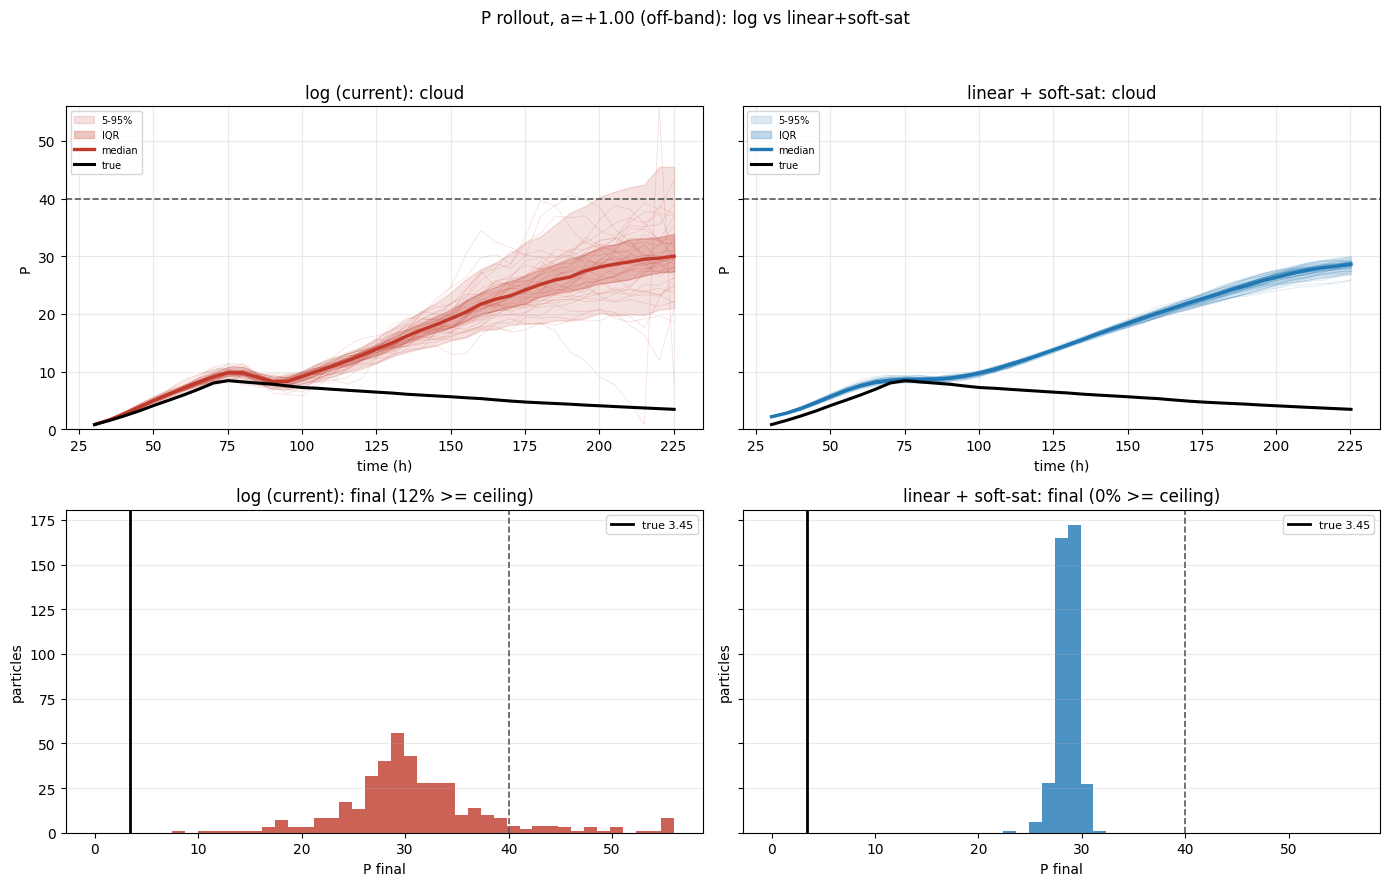

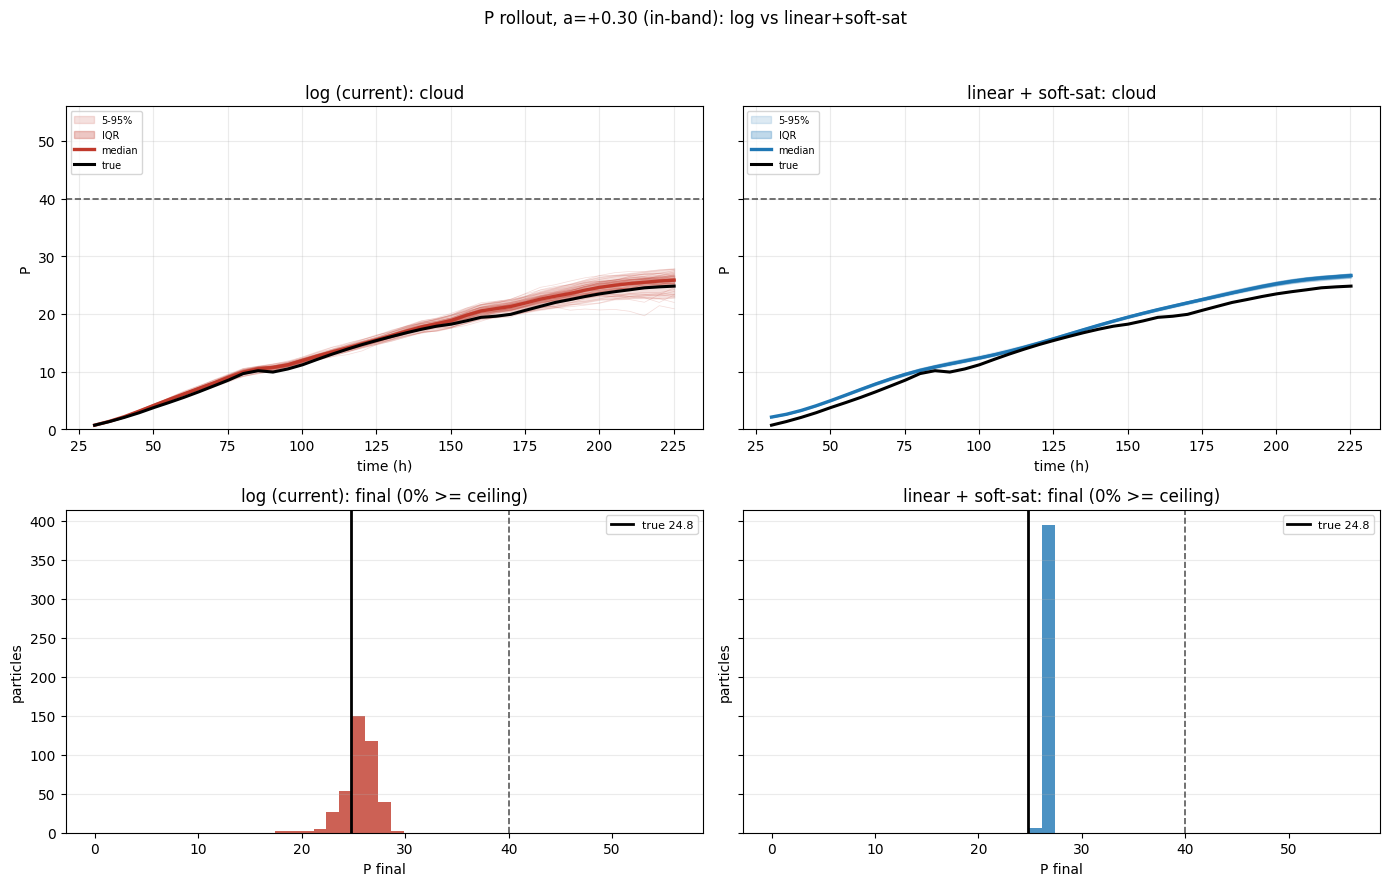

In [7]:
def figure_main(R, a):
    r = R["rolls"][a]; CEIL = R["ceil"]; times = r["times"]; v_true = r["v_true"]; YMAX = 1.4 * CEIL
    fig, ax = plt.subplots(2, 2, figsize=(14, 9), sharex="row", sharey="row")
    for j, e in enumerate(R["encoders"]):
        cloud = r["clouds"][e.name][0]; disp = np.clip(cloud, 0, YMAX)
        qs = np.percentile(cloud, [5, 25, 50, 75, 95], axis=1); axc = ax[0, j]
        axc.plot(times, disp[:, np.linspace(0, cloud.shape[1]-1, 40).astype(int)], color=e.color, lw=0.5, alpha=0.18)
        axc.fill_between(times, np.clip(qs[0],0,YMAX), np.clip(qs[4],0,YMAX), color=e.color, alpha=0.15, label="5-95%")
        axc.fill_between(times, np.clip(qs[1],0,YMAX), np.clip(qs[3],0,YMAX), color=e.color, alpha=0.28, label="IQR")
        axc.plot(times, np.clip(qs[2],0,YMAX), color=e.color, lw=2.4, label="median")
        axc.plot(times, v_true, "k-", lw=2.2, label="true"); axc.axhline(CEIL, color="0.35", ls="--", lw=1.2)
        axc.set_ylim(0, YMAX); axc.set_xlabel("time (h)"); axc.set_ylabel(R["ch"]); axc.grid(alpha=0.25)
        axc.set_title(f"{e.name}: cloud"); axc.legend(fontsize=7, loc="upper left")
        vf = cloud[-1]; h = ax[1, j]
        h.hist(np.clip(vf, 0, YMAX), bins=np.linspace(0, YMAX, 46), color=e.color, alpha=0.8)
        h.axvline(v_true[-1], color="k", lw=2, label=f"true {v_true[-1]:.3g}"); h.axvline(CEIL, color="0.35", ls="--", lw=1.2)
        h.set_xlabel(f"{R['ch']} final"); h.set_ylabel("particles"); h.grid(alpha=0.25, axis="y")
        h.set_title(f"{e.name}: final ({np.mean(vf >= 0.95*CEIL):.0%} >= ceiling)"); h.legend(fontsize=8)
    tag = "in-band" if r["inband"] else "off-band"
    fig.suptitle(f"{R['ch']} rollout, a={a:+.2f} ({tag}): log vs linear+soft-sat", fontsize=12)
    fig.tight_layout(rect=(0, 0, 1, 0.95)); return fig

OUT = REPO / "results" / "single_phase" / "encoding_isolation"; OUT.mkdir(parents=True, exist_ok=True)
for a in (A_ROLL, A_ROLL_INBAND):
    figure_main(R, a).savefig(OUT / f"rung2_{CHANNEL}_main_a{a:+.2f}.png", dpi=130, bbox_inches="tight")
plt.show()

## 4 · Verification #1 — is linear's tight IQR honest, or soft-clamp compression?

Two reads. **Left:** the linear cloud's *latent* `z` spread vs its clamped physical spread — if the
latent IQR is itself tiny, the tight physical cloud is **genuine** (small process noise); if the
latent (or raw pre-clamp) spread is healthy but the clamped physical IQR is crushed, the **soft-clamp
is compressing**. **Right:** a `LIN_BETA` decode-sweep on the *same* rollout (the GP is beta-free) — if
softening beta widens the final IQR, compression is confirmed.

a=+0.30: linear tight-IQR verdict -> GENUINE (latent spread itself tiny)
a=+1.00: linear tight-IQR verdict -> genuine (clamp ~inactive)


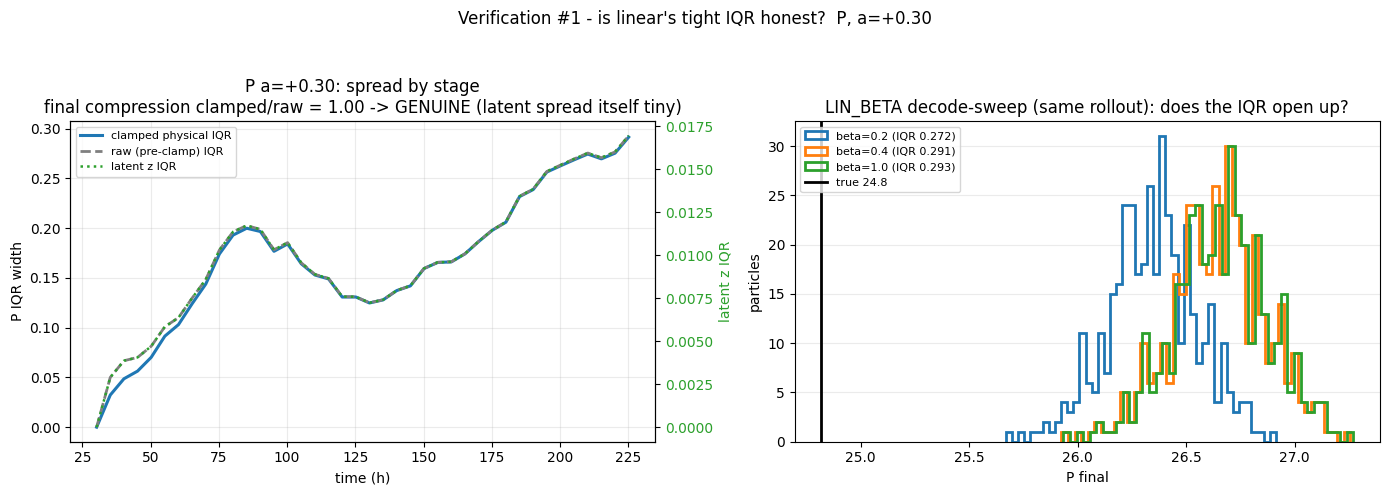

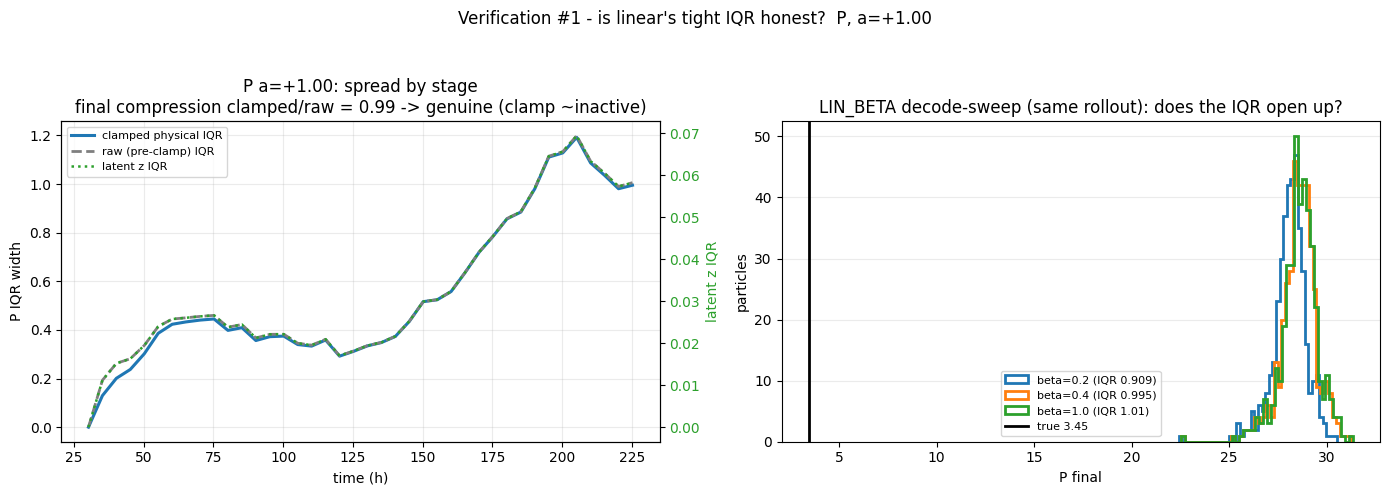

In [8]:
def figure_honesty(R, a, beta_sweep):
    r = R["rolls"][a]; CEIL = R["ceil"]; times = r["times"]; v_true = r["v_true"]
    lin = next(e for e in R["encoders"] if isinstance(e, LinEnc))
    phys, z = r["clouds"][lin.name]; raw = lin.decode_raw(z)
    lat_iqr = np.percentile(z, 75, axis=1) - np.percentile(z, 25, axis=1)
    raw_iqr = np.percentile(raw, 75, axis=1) - np.percentile(raw, 25, axis=1)
    cl_iqr = np.percentile(phys, 75, axis=1) - np.percentile(phys, 25, axis=1)
    comp = cl_iqr[-1] / raw_iqr[-1] if raw_iqr[-1] > 1e-9 else 1.0
    verdict = ("GENUINE (latent spread itself tiny)" if lat_iqr[-1] < 0.02 else
               ("COMPRESSION (clamp crushes a healthy raw spread)" if comp < 0.5 else "genuine (clamp ~inactive)"))
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    a0 = ax[0]; a0.plot(times, cl_iqr, color=lin.color, lw=2.2, label="clamped physical IQR")
    a0.plot(times, raw_iqr, color="#7f7f7f", lw=2.0, ls="--", label="raw (pre-clamp) IQR")
    a0b = a0.twinx(); a0b.plot(times, lat_iqr, color="#2ca02c", lw=1.8, ls=":", label="latent z IQR")
    a0b.set_ylabel("latent z IQR", color="#2ca02c"); a0b.tick_params(axis="y", labelcolor="#2ca02c")
    a0.set_xlabel("time (h)"); a0.set_ylabel(f"{R['ch']} IQR width"); a0.grid(alpha=0.25)
    a0.set_title(f"{R['ch']} a={a:+.2f}: spread by stage\nfinal compression clamped/raw = {comp:.2f} -> {verdict}")
    h1, l1 = a0.get_legend_handles_labels(); h2, l2 = a0b.get_legend_handles_labels()
    a0.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left")
    a1 = ax[1]
    for beta in beta_sweep:
        vf = _soft_clamp(_as_t(raw[-1]), 0.0, CEIL, beta).cpu().numpy()
        iqr = np.percentile(vf, 75) - np.percentile(vf, 25)
        a1.hist(np.clip(vf, -0.1*CEIL, 1.4*CEIL), bins=44, histtype="step", lw=2,
                label=f"beta={beta} (IQR {iqr:.3g})")
    a1.axvline(v_true[-1], color="k", lw=2, label=f"true {v_true[-1]:.3g}")
    a1.set_xlabel(f"{R['ch']} final"); a1.set_ylabel("particles"); a1.grid(alpha=0.25, axis="y")
    a1.set_title("LIN_BETA decode-sweep (same rollout): does the IQR open up?"); a1.legend(fontsize=8)
    fig.suptitle(f"Verification #1 - is linear's tight IQR honest?  {R['ch']}, a={a:+.2f}", fontsize=12)
    fig.tight_layout(rect=(0, 0, 1, 0.94)); return fig, verdict

for a in (A_ROLL_INBAND, A_ROLL):
    fig, verdict = figure_honesty(R, a, LIN_BETA_SWEEP)
    fig.savefig(OUT / f"rung2_{CHANNEL}_honesty_a{a:+.2f}.png", dpi=130, bbox_inches="tight")
    print(f"a={a:+.2f}: linear tight-IQR verdict -> {verdict}")
plt.show()

## 5 · Verification #2 — do X and Wt carry the same log low-bias?

Run the whole comparison for P, X, Wt. The decisive column is **in-band bias** (median vs true where
the GP is confident and *should* nail it): if log under-predicts on X and Wt too — and X compounds
into P — the low-P bias in full-system rollouts is the growth channels' shared log encoding.

In [9]:
torch.manual_seed(0); np.random.seed(0)
rows = []
sweep = {}
for ch in CHANNELS_SWEEP:
    Rc = run_channel(ch, [A_ROLL_INBAND, A_ROLL], N_EPOCH_SWEEP, lin_span=LIN_SPAN, lin_beta=LIN_BETA)
    sweep[ch] = Rc
    for e in Rc["encoders"]:
        ri = Rc["rolls"][A_ROLL_INBAND]; ro = Rc["rolls"][A_ROLL]
        vf_in = ri["clouds"][e.name][0][-1]; vf_off = ro["clouds"][e.name][0][-1]
        bias = np.median(vf_in) / ri["v_true"][-1] - 1.0 if ri["v_true"][-1] else np.nan
        rows.append(dict(channel=ch, encoding=e.name, R2=Rc["fits"][e.name]["r2"],
                         inband_median=np.median(vf_in), inband_true=ri["v_true"][-1],
                         inband_bias=bias, offband_ceil_frac=np.mean(vf_off >= 0.95 * Rc["ceil"])))

import pandas as pd
df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda x: f"{x:.3g}")
print(df.to_string(index=False))
df.to_csv(OUT / "rung2_channel_sweep.csv", index=False)

channel          encoding    R2  inband_median  inband_true  inband_bias  offband_ceil_frac
      P     log (current) 0.999           26.6         24.8       0.0707              0.242
      P linear + soft-sat 0.732           26.6         24.8       0.0708                  0
      X     log (current)  0.98           20.9         20.6       0.0161               0.09
      X linear + soft-sat 0.883           20.9         20.6       0.0151                  0
     Wt     log (current) 0.408       1.03e+05     1.06e+05      -0.0264                  0
     Wt linear + soft-sat 0.373       1.03e+05     1.06e+05      -0.0249                  0


saved -> /Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/pensim_mcpilco/results/single_phase/encoding_isolation


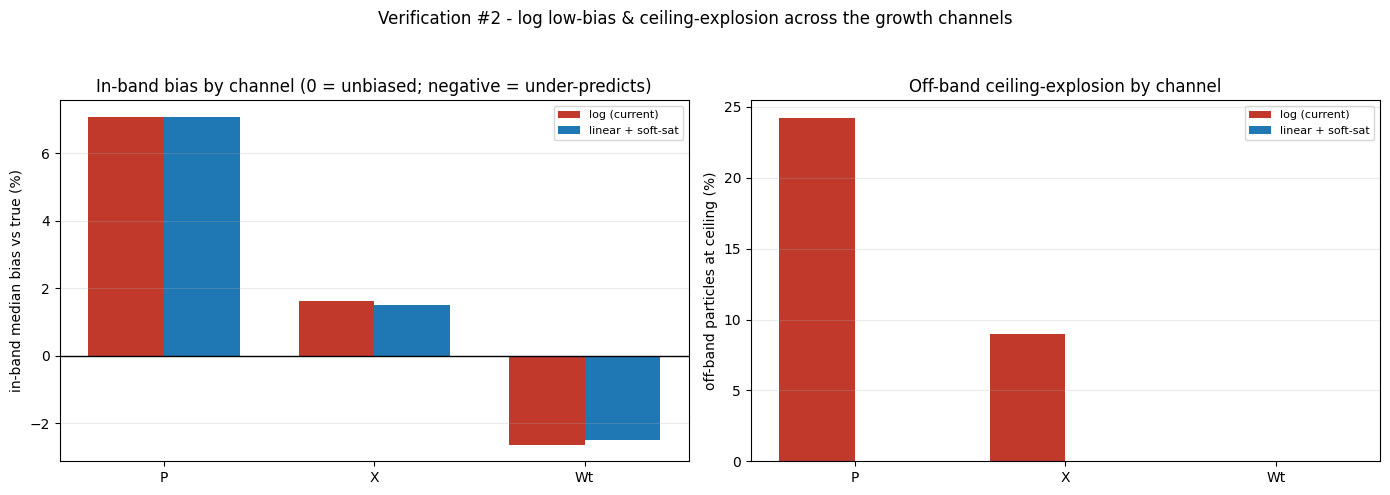

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
chs = CHANNELS_SWEEP; xpos = np.arange(len(chs)); wd = 0.36
for k, enc_name in enumerate(["log (current)", "linear + soft-sat"]):
    col = "#c0392b" if k == 0 else "#1f77b4"
    b = [df[(df.channel == c) & (df.encoding == enc_name)]["inband_bias"].iloc[0] * 100 for c in chs]
    ax[0].bar(xpos + (k - 0.5) * wd, b, wd, color=col, label=enc_name)
ax[0].axhline(0, color="k", lw=1); ax[0].set_xticks(xpos); ax[0].set_xticklabels(chs)
ax[0].set_ylabel("in-band median bias vs true (%)"); ax[0].grid(alpha=0.25, axis="y")
ax[0].set_title("In-band bias by channel (0 = unbiased; negative = under-predicts)"); ax[0].legend(fontsize=8)
for k, enc_name in enumerate(["log (current)", "linear + soft-sat"]):
    col = "#c0392b" if k == 0 else "#1f77b4"
    b = [df[(df.channel == c) & (df.encoding == enc_name)]["offband_ceil_frac"].iloc[0] * 100 for c in chs]
    ax[1].bar(xpos + (k - 0.5) * wd, b, wd, color=col, label=enc_name)
ax[1].set_xticks(xpos); ax[1].set_xticklabels(chs); ax[1].set_ylabel("off-band particles at ceiling (%)")
ax[1].grid(alpha=0.25, axis="y"); ax[1].set_title("Off-band ceiling-explosion by channel"); ax[1].legend(fontsize=8)
fig.suptitle("Verification #2 - log low-bias & ceiling-explosion across the growth channels", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(OUT / "rung2_channel_sweep.png", dpi=130, bbox_inches="tight"); print("saved ->", OUT); plt.show()

## 6 · Read-out

**Verification #1 (honesty):** if the latent `z` IQR is itself tiny and the `LIN_BETA` sweep does not
open the final IQR, the tight in-band cloud is **genuine** (the in-band dynamics really are near
deterministic and the GP learned small process noise). If softening beta widens the IQR, the
soft-clamp is **compressing** near the ceiling — lift ceiling headroom or lower `LIN_BETA`.

**Verification #2 (X, Wt):** if log's in-band bias bars are negative for X and Wt too, all three
growth channels share the convex-`exp()` low-bias; since X compounds into P, that doubles down on the
under-prediction — a single, coherent root cause for the full-system imagined rollouts landing at
1-4 g/L instead of ~28.

**If both hold →** promote linear+soft-sat (with data-driven spans) for Wt/X/P in the wrapper. That is
the *next* step, not this notebook: it needs `STATE_LOG_CHANNELS` updated too (drop Wt/X/P) and the
linear `STATE_RANGES` set to the reachable spans, then a re-run of `imagined_vs_real.py` with success
criterion "imagined final-P median near real ~28, and Spearman(cost, yield) finally negative".